In [6]:
import wandb
from tqdm import tqdm
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

# Enable high-quality vector graphics output
%config InlineBackend.figure_formats = ['svg']

runs = wandb.Api().runs("team-cr/DRAEM_seminar_AD")

# Extract data from runs
data = []
for run in runs:
    if 'lr_scheduler' in run.config and run.summary and 'with_eval' in run.tags and run.state == 'finished':
        record = {
            'cos': run.config['lr_scheduler'] == 'cosine_annealing',
            'obj_name': run.config.get('obj_name', 'unknown')
        }
        # Extract eval metrics from summary
        for key in run.summary.keys():
            if key.startswith('eval/'):
                record[key] = run.summary[key]
        if len(record) > 2:  # Only add if we have eval metrics
            data.append(record)

df_analysis = pd.DataFrame(data)

# Remove duplicate capsule entries to have one per cos/obj_name combination
capsule_cos_false = df_analysis[(df_analysis['obj_name'] == 'capsule') & (df_analysis['cos'] == False)]
capsule_cos_true = df_analysis[(df_analysis['obj_name'] == 'capsule') & (df_analysis['cos'] == True)]

# Keep only the first entry for each combination
indices_to_drop = []
if len(capsule_cos_false) > 1:
    indices_to_drop.extend(capsule_cos_false.index[1:].tolist())
if len(capsule_cos_true) > 1:
    indices_to_drop.extend(capsule_cos_true.index[1:].tolist())

df_analysis = df_analysis.drop(indices_to_drop)
print(f"Removed {len(indices_to_drop)} duplicate capsule entries")


amp_true_all = df_analysis[df_analysis['cos'] == True]
amp_false_all = df_analysis[df_analysis['cos'] == False]

print(f"Total runs with cos=True: {len(amp_true_all)}")
print(f"Total runs with cos=False: {len(amp_false_all)}")

eval_metrics = [col for col in df_analysis.columns if col.startswith('eval/')]

for metric in eval_metrics:
    if metric in amp_true_all.columns and metric in amp_false_all.columns:
        true_vals = amp_true_all[metric].dropna()
        false_vals = amp_false_all[metric].dropna()
        
        if len(true_vals) > 0 and len(false_vals) > 0:
            # Calculate statistics
            t_stat, p_value = stats.ttest_ind(true_vals, false_vals, nan_policy='omit')
            
            # Calculate correlation (point-biserial correlation between binary amp and metric)
            amp_numeric = df_analysis['cos'].astype(int)
            valid_idx = df_analysis[metric].notna()
            if valid_idx.sum() > 1:
                corr, corr_p = stats.pointbiserialr(amp_numeric[valid_idx], df_analysis[metric][valid_idx])
            else:
                corr, corr_p = np.nan, np.nan
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt(((len(true_vals)-1)*true_vals.std()**2 + (len(false_vals)-1)*false_vals.std()**2) / (len(true_vals)+len(false_vals)-2))
            cohens_d = (true_vals.mean() - false_vals.mean()) / pooled_std if pooled_std > 0 else 0
            

# Analyze by object name
for obj_name in sorted(df_analysis['obj_name'].unique()):
    df_obj = df_analysis[df_analysis['obj_name'] == obj_name]
    amp_true = df_obj[df_obj['cos'] == True]
    amp_false = df_obj[df_obj['cos'] == False]
    
    # Analyze each eval metric
    eval_metrics = [col for col in df_obj.columns if col.startswith('eval/')]
    
    for metric in eval_metrics:
        if metric in amp_true.columns and metric in amp_false.columns:
            true_vals = amp_true[metric].dropna()
            false_vals = amp_false[metric].dropna()
            
            if len(true_vals) > 0 and len(false_vals) > 0:
                # Calculate statistics
                t_stat, p_value = stats.ttest_ind(true_vals, false_vals, nan_policy='omit')
                
                # Calculate correlation (point-biserial correlation between binary amp and metric)
                amp_numeric = df_obj['cos'].astype(int)
                valid_idx = df_obj[metric].notna()
                if valid_idx.sum() > 1:
                    corr, corr_p = stats.pointbiserialr(amp_numeric[valid_idx], df_obj[metric][valid_idx])
                else:
                    corr, corr_p = np.nan, np.nan

Removed 2 duplicate capsule entries
Total runs with cos=True: 15
Total runs with cos=False: 15


/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:6195: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:6195: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:6195: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:6195: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats

In [7]:
baseline_metrics = [
    {"obj_name": "bottle",      'eval/auroc_pixel': 0.991, 'eval/ap_pixel': 0.865, 'eval/auroc_image': 0.992},
    {"obj_name": "capsule",     'eval/auroc_pixel': 0.943, 'eval/ap_pixel': 0.494, 'eval/auroc_image': 0.985},
    {"obj_name": "grid",        'eval/auroc_pixel': 0.997, 'eval/ap_pixel': 0.657, 'eval/auroc_image': 0.999},
    {"obj_name": "leather",     'eval/auroc_pixel': 0.986, 'eval/ap_pixel': 0.753, 'eval/auroc_image': 1.000},
    {"obj_name": "pill",        'eval/auroc_pixel': 0.976, 'eval/ap_pixel': 0.485, 'eval/auroc_image': 0.989},
    {"obj_name": "tile",        'eval/auroc_pixel': 0.992, 'eval/ap_pixel': 0.923, 'eval/auroc_image': 0.996},
    {"obj_name": "transistor",  'eval/auroc_pixel': 0.909, 'eval/ap_pixel': 0.507, 'eval/auroc_image': 0.931},
    {"obj_name": "zipper",      'eval/auroc_pixel': 0.988, 'eval/ap_pixel': 0.815, 'eval/auroc_image': 1.000},
    {"obj_name": "cable",       'eval/auroc_pixel': 0.947, 'eval/ap_pixel': 0.524, 'eval/auroc_image': 0.918},
    {"obj_name": "carpet",      'eval/auroc_pixel': 0.955, 'eval/ap_pixel': 0.535, 'eval/auroc_image': 0.970},
    {"obj_name": "hazelnut",    'eval/auroc_pixel': 0.997, 'eval/ap_pixel': 0.929, 'eval/auroc_image': 1.000},
    {"obj_name": "metal nut",   'eval/auroc_pixel': 0.995, 'eval/ap_pixel': 0.963, 'eval/auroc_image': 0.987},
    {"obj_name": "screw",       'eval/auroc_pixel': 0.976, 'eval/ap_pixel': 0.582, 'eval/auroc_image': 0.939},
    {"obj_name": "toothbrush",  'eval/auroc_pixel': 0.981, 'eval/ap_pixel': 0.447, 'eval/auroc_image': 1.000},
    {"obj_name": "wood",        'eval/auroc_pixel': 0.964, 'eval/ap_pixel': 0.777, 'eval/auroc_image': 0.991},
]

/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/home/woody/iwai/iwai128h/software/private/conda/envs/draem/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


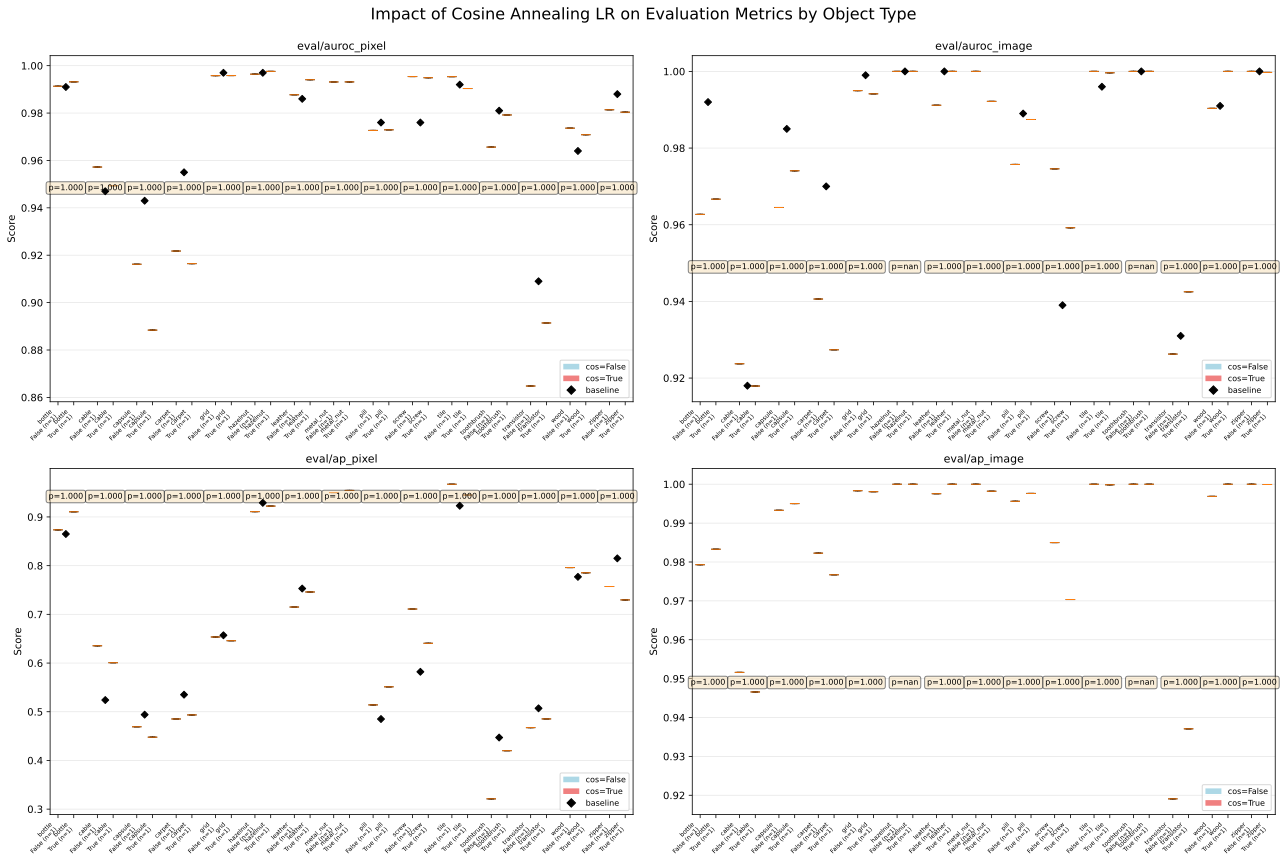

/tmp/ipykernel_910135/3177317082.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_910135/3177317082.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_910135/3177317082.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_910135/3177317082.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

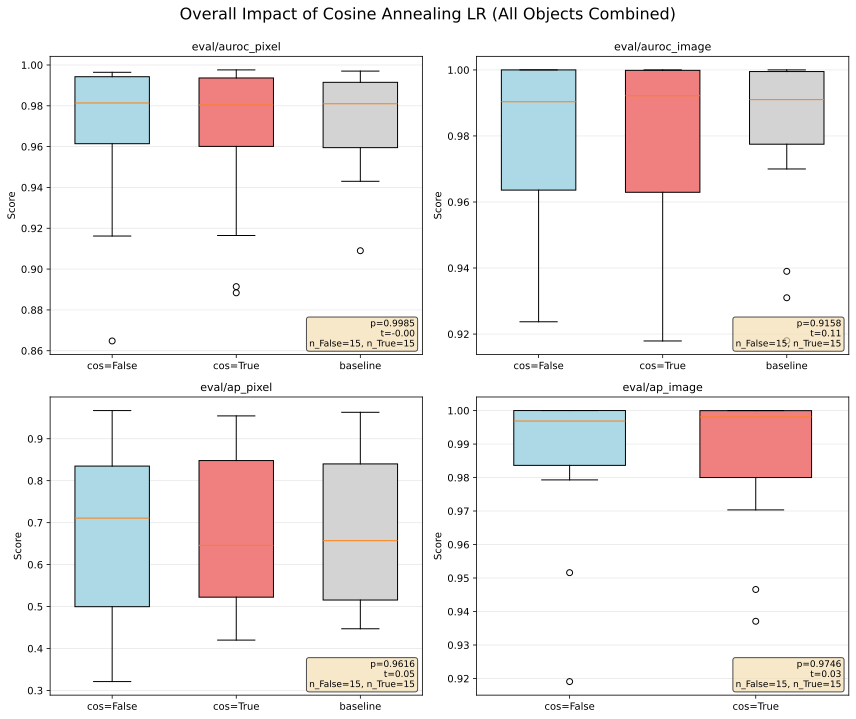

eval/auroc_pixel: r=-0.0004, p=0.9985
eval/auroc_image: r=0.0201, p=0.9158
eval/ap_pixel: r=0.0092, p=0.9616
eval/ap_image: r=0.0061, p=0.9746


In [8]:
# Create visualization by object
obj_names = sorted(df_analysis['obj_name'].unique())
metrics_to_plot = ['eval/auroc_pixel', 'eval/auroc_image', 'eval/ap_pixel', 'eval/ap_image']

# Baseline DataFrame (if provided)
baseline_df = None
if 'baseline_metrics' in globals():
    baseline_df = pd.DataFrame(baseline_metrics)

# Create a figure with subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Impact of Cosine Annealing LR on Evaluation Metrics by Object Type', fontsize=16, y=0.995)

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for grouped box plot
    positions = []
    data_plot = []
    labels = []
    colors = []
    obj_center_pos = {}
    
    pos = 0
    for obj_idx, obj_name in enumerate(obj_names):
        df_obj = df_analysis[df_analysis['obj_name'] == obj_name]
        
        if metric in df_obj.columns:
            positions_this_obj = []
            
            amp_false_vals = df_obj[df_obj['cos'] == False][metric].dropna()
            amp_true_vals = df_obj[df_obj['cos'] == True][metric].dropna()
            
            if len(amp_false_vals) > 0:
                positions.append(pos)
                positions_this_obj.append(pos)
                data_plot.append(amp_false_vals)
                labels.append(f'{obj_name}\nFalse (n={len(amp_false_vals)})')
                colors.append('lightblue')
                pos += 1
            
            if len(amp_true_vals) > 0:
                positions.append(pos)
                positions_this_obj.append(pos)
                data_plot.append(amp_true_vals)
                labels.append(f'{obj_name}\nTrue (n={len(amp_true_vals)})')
                colors.append('lightcoral')
                pos += 1
            
            # Calculate and display correlation for this object
            amp_numeric = df_obj['cos'].astype(int)
            valid_idx = df_obj[metric].notna()
            if valid_idx.sum() > 1:
                corr, corr_p = stats.pointbiserialr(amp_numeric[valid_idx], df_obj[metric][valid_idx])
                
                # Add p-value text to the plot (center between boxes for this object)
                if len(positions_this_obj) >= 1:
                    text_pos = (positions_this_obj[0] + positions_this_obj[-1]) / 2
                    y_pos = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                    ax.text(text_pos, y_pos * 0.95, f'p={corr_p:.3f}', 
                           ha='center', va='top', fontsize=8, 
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Track center x-position for baseline marker overlay
            if len(positions_this_obj) > 0:
                obj_center_pos[obj_name] = sum(positions_this_obj) / len(positions_this_obj)
            
            pos += 0.5  # Add spacing between objects
    
    # Create box plot
    bp = ax.boxplot(data_plot, positions=positions, widths=0.6, patch_artist=True)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Overlay baseline markers (if available for this metric)
    if baseline_df is not None and metric in baseline_df.columns:
        for _, row in baseline_df.iterrows():
            obj = row['obj_name']
            val = row.get(metric, None)
            if obj in obj_center_pos and val is not None and pd.notna(val):
                ax.scatter(obj_center_pos[obj], val, marker='D', c='black', s=24, zorder=3)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(metric, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [Patch(facecolor='lightblue', label='cos=False'),
                      Patch(facecolor='lightcoral', label='cos=True')]
    if baseline_df is not None and metric in baseline_df.columns:
        legend_elements.append(Line2D([0], [0], marker='D', color='black', label='baseline', markersize=6, linewidth=0))
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

fig.savefig('figures/cos_comparison_by_object.svg', format='svg', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

# Create overall comparison plot (not differentiated by object)
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
fig2.suptitle('Overall Impact of Cosine Annealing LR (All Objects Combined)', fontsize=16, y=0.995)

for idx, metric in enumerate(metrics_to_plot):
    if metric in df_analysis.columns:
        ax = axes2[idx // 2, idx % 2]
        
        amp_false_vals = df_analysis[df_analysis['cos'] == False][metric].dropna()
        amp_true_vals = df_analysis[df_analysis['cos'] == True][metric].dropna()
        
        # Baseline distribution for this metric (across objects), if available
        baseline_vals = None
        if baseline_df is not None and metric in baseline_df.columns:
            baseline_vals = baseline_df[metric].dropna()
        
        data_plot = [amp_false_vals, amp_true_vals] + ([baseline_vals] if baseline_vals is not None and len(baseline_vals) > 0 else [])
        labels = ['cos=False', 'cos=True'] + (['baseline'] if baseline_vals is not None and len(baseline_vals) > 0 else [])
        
        bp = ax.boxplot(data_plot, labels=labels, patch_artist=True, widths=0.6)
        colors2 = ['lightblue', 'lightcoral'] + (['lightgray'] if baseline_vals is not None and len(baseline_vals) > 0 else [])
        for patch, color in zip(bp['boxes'], colors2):
            patch.set_facecolor(color)
        
        # Calculate and display statistics (amp vs metric)
        amp_numeric = df_analysis['cos'].astype(int)
        valid_idx = df_analysis[metric].notna()
        if valid_idx.sum() > 1:
            corr, corr_p = stats.pointbiserialr(amp_numeric[valid_idx], df_analysis[metric][valid_idx])
            t_stat, p_value = stats.ttest_ind(amp_true_vals, amp_false_vals, nan_policy='omit')
            
            # Add statistics text
            stats_text = f'p={corr_p:.4f}\nt={t_stat:.2f}\nn_False={len(amp_false_vals)}, n_True={len(amp_true_vals)}'
            ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
                   ha='right', va='bottom', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
        
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(metric, fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

fig2.savefig('figures/cos_comparison.svg', format='svg', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

for metric in metrics_to_plot:
    if metric in df_analysis.columns:
        amp_numeric = df_analysis['cos'].astype(int)
        valid_idx = df_analysis[metric].notna()
        if valid_idx.sum() > 1:
            corr, corr_p = stats.pointbiserialr(amp_numeric[valid_idx], df_analysis[metric][valid_idx])
            print(f"{metric}: r={corr:.4f}, p={corr_p:.4f}")